# CNN + LSTM — Temporal Classification

Takes the EfficientNet-B4 feature sequences from the previous step and trains a **bidirectional LSTM** to classify driver behavior.

Each sequence is `(16, 1792)` — 16 frames × 1792-dim CNN embeddings.  
Output: **Drink / Phone / Safe**

In [1]:
!pip install torchmetrics seaborn scikit-learn ipython-autotime -q
%load_ext autotime

time: 249 µs (started: 2026-04-08 19:55:32 +00:00)


In [2]:
import os, gc, shutil
import numpy as np
import torch
import torch.nn as nn
from collections import Counter, defaultdict
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchmetrics.classification import MulticlassF1Score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

drive.mount('/content/drive')

use_cuda  = torch.cuda.is_available()
dev       = 'cuda' if use_cuda else 'cpu'
amp_dtype = torch.bfloat16 if (use_cuda and torch.cuda.is_bf16_supported()) else None

if use_cuda:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark        = True

print(f'device : {dev}')
if use_cuda:
    print(f'gpu    : {torch.cuda.get_device_name(0)}')
    print(f'amp    : {amp_dtype}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device : cuda
gpu    : NVIDIA L4
amp    : torch.bfloat16
time: 8.87 s (started: 2026-04-08 19:55:32 +00:00)


## Features — Copy to Local

Thousands of small `.npy` files read much faster from `/content` than from Drive.

In [3]:
drive_feats = '/content/drive/MyDrive/DriveGuard/CNN_Features'
local_feats = '/content/cnn_features'

if os.path.exists(local_feats):
    print('already local, skipping copy')
else:
    n = sum(len(fs) for _, _, fs in os.walk(drive_feats))
    print(f'copying {n:,} files...')
    shutil.copytree(drive_feats, local_feats)
    print('done')

already local, skipping copy
time: 751 µs (started: 2026-04-08 19:55:41 +00:00)


## Config

In [4]:
# all tunable params in one place
cfg = {
    'camera'        : 'a_column_co_driver',
    'classes'       : ['Drink', 'Phone', 'Safe'],
    'num_frames'    : 16,
    'input_dim'     : 1792,    # EfficientNet-B4 output
    'num_classes'   : 3,
    'feats_root'    : local_feats,

    # LSTM
    'hidden_dim'    : 512,
    'num_layers'    : 2,
    'bidir'         : True,
    'dropout'       : 0.3,
    'noise_std'     : 0.03,

    # training
    'batch_size'    : 32,
    'label_smooth'  : 0.1,
    'epochs_warmup' : 5,
    'epochs_full'   : 40,
    'patience'      : 10,
    'grad_clip'     : 1.0,
    'lr_warmup'     : 1e-3,
    'lr_enc'        : 2e-5,
    'lr_head'       : 5e-5,
    'weight_decay'  : 0.1,
    'ckpt'          : 'lstm_temporal_head_model.pth',
}

time: 692 µs (started: 2026-04-08 19:55:41 +00:00)


## Dataset

Loads `.npy` sequences for a single camera. Pads short sequences with zeros (shouldn't happen with a clean dataset).

In [5]:
class CamSeqDataset(Dataset):
    def __init__(self, root, split, cfg):
        self.T       = cfg['num_frames']
        self.D       = cfg['input_dim']
        self.items   = []
        self.targets = []

        for li, cls in enumerate(cfg['classes']):
            d = os.path.join(root, split, cls)
            if not os.path.isdir(d):
                continue
            for f in sorted(os.listdir(d)):
                if f.endswith('.npy') and f.startswith(cfg['camera']):
                    self.items.append((li, os.path.join(d, f)))
                    self.targets.append(li)

        counts = Counter(self.targets)
        print(f'{split:5s}  ' + '  '.join(f'{cls}={counts[i]}' for i, cls in enumerate(cfg['classes'])))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        label, path = self.items[idx]
        x = np.load(path).astype(np.float32)
        if x.shape[0] < self.T:
            x = np.vstack([x, np.zeros((self.T - x.shape[0], self.D), dtype=np.float32)])
        return torch.from_numpy(x[:self.T]), torch.tensor(label, dtype=torch.long)

time: 1.86 ms (started: 2026-04-08 19:55:41 +00:00)


In [6]:
train_ds = CamSeqDataset(cfg['feats_root'], 'train', cfg)
val_ds   = CamSeqDataset(cfg['feats_root'], 'val',   cfg)
test_ds  = CamSeqDataset(cfg['feats_root'], 'test',  cfg)

counts   = Counter(train_ds.targets)
wts      = torch.tensor([1.0 / counts[l] for l in train_ds.targets], dtype=torch.float32)
sampler  = WeightedRandomSampler(wts, len(wts), replacement=True)

nw = 2
train_loader = DataLoader(train_ds, cfg['batch_size'], sampler=sampler,  num_workers=nw, pin_memory=use_cuda, persistent_workers=True)
val_loader   = DataLoader(val_ds,   cfg['batch_size'], shuffle=False,    num_workers=nw, pin_memory=use_cuda, persistent_workers=True)
test_loader  = DataLoader(test_ds,  cfg['batch_size'], shuffle=False,    num_workers=nw, pin_memory=use_cuda, persistent_workers=True)

total = sum(counts.values())
cw    = torch.tensor([total / (cfg['num_classes'] * counts[i]) for i in range(cfg['num_classes'])], dtype=torch.float32).to(dev)
print(f'class weights: {[round(w,3) for w in cw.tolist()]}')

train  Drink=760  Phone=506  Safe=757
val    Drink=209  Phone=125  Safe=209
test   Drink=311  Phone=148  Safe=323
class weights: [0.887, 1.333, 0.891]
time: 144 ms (started: 2026-04-08 19:55:41 +00:00)


## Model

Two-component architecture:

**`LSTMEncoder`** — projects each 1792-dim frame to `hidden_dim`, then runs a 2-layer bidirectional LSTM. Final representation is the last hidden states of both directions concatenated → `hidden_dim × 2 = 1024`.

**`DriveGuardLSTM`** — wraps the encoder with dropout + a linear head. Optional Gaussian noise on input features during training helps generalization.

In [7]:
class LSTMEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        H = cfg['hidden_dim']

        self.proj = nn.Sequential(
            nn.Linear(cfg['input_dim'], H),
            nn.LayerNorm(H),
            nn.GELU(),
        )
        self.lstm = nn.LSTM(
            input_size    = H,
            hidden_size   = H,
            num_layers    = cfg['num_layers'],
            batch_first   = True,
            bidirectional = cfg['bidir'],
            dropout       = cfg['dropout'] if cfg['num_layers'] > 1 else 0.0,
        )
        self.bidir = cfg['bidir']

    def forward(self, x):
        x = self.proj(x)                 # (B, T, H)
        _, (h, _) = self.lstm(x)         # h: (n_layers * dirs, B, H)
        if self.bidir:
            return torch.cat([h[-2], h[-1]], dim=1)   # (B, H*2)
        return h[-1]                                   # (B, H)


class DriveGuardLSTM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        out_dim         = cfg['hidden_dim'] * (2 if cfg['bidir'] else 1)
        self.encoder    = LSTMEncoder(cfg)
        self.drop       = nn.Dropout(cfg['dropout'])
        self.head       = nn.Linear(out_dim, cfg['num_classes'])
        self.noise_std  = cfg['noise_std']

    def forward(self, x):
        if self.training and self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return self.head(self.drop(self.encoder(x)))

time: 1.77 ms (started: 2026-04-08 19:55:41 +00:00)


In [8]:
net    = DriveGuardLSTM(cfg).to(dev)
n_par  = sum(p.numel() for p in net.parameters())
print(f'DriveGuardLSTM  {n_par:,} params  ({n_par/1e6:.2f}M)')

# sanity check
with torch.no_grad():
    dummy = torch.zeros(2, cfg['num_frames'], cfg['input_dim']).to(dev)
    print(f'output shape: {net(dummy).shape}')   # expect [2, 3]

DriveGuardLSTM  11,424,259 params  (11.42M)
output shape: torch.Size([2, 3])
time: 298 ms (started: 2026-04-08 19:55:41 +00:00)


## Ablation Study

Short runs to find the best config before committing to a full training run. Winner = best Phone F1 (tiebreak: macro F1).

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma, weight, label_smoothing):
        super().__init__()
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(weight=weight, reduction='none', label_smoothing=label_smoothing)

    def forward(self, logits, y):
        ce = self.ce(logits, y)
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()

runs = [
    dict(name='baseline',      dropout=0.30, noise=0.03, phone_w=1.0, focal=False, gamma=0.0),
    dict(name='phone_w2.5',    dropout=0.30, noise=0.03, phone_w=2.5, focal=False, gamma=0.0),
    dict(name='phone_w4',      dropout=0.30, noise=0.03, phone_w=4.0, focal=False, gamma=0.0),
    dict(name='phone_w5',      dropout=0.30, noise=0.03, phone_w=5.0, focal=False, gamma=0.0),
    dict(name='noise_med',     dropout=0.30, noise=0.07, phone_w=2.5, focal=False, gamma=0.0),
    dict(name='dropout_low',   dropout=0.20, noise=0.03, phone_w=2.5, focal=False, gamma=0.0),
    dict(name='dropout_high',  dropout=0.35, noise=0.03, phone_w=2.5, focal=False, gamma=0.0),
    dict(name='focal_mild',    dropout=0.30, noise=0.03, phone_w=3.0, focal=True,  gamma=1.5),
]

f1_mac = MulticlassF1Score(num_classes=3, average='macro').to(dev)
f1_per = MulticlassF1Score(num_classes=3, average=None).to(dev)

ABL_W, ABL_F = 5, 25
results = []

for r in runs:
    print(f"\n--- {r['name']} ---", flush=True)
    rc  = {**cfg, 'dropout': r['dropout'], 'noise_std': r['noise']}
    m   = DriveGuardLSTM(rc).to(dev)
    w   = cw.clone();  w[1] *= r['phone_w'];  w /= w.mean()
    crit = FocalLoss(r['gamma'], w, cfg['label_smooth']) if r['focal'] \
           else nn.CrossEntropyLoss(weight=w, label_smoothing=cfg['label_smooth'])

    def _step(loader, opt=None, sched=None):
        if opt: m.train()
        else:   m.eval();  f1_mac.reset();  f1_per.reset()
        tot, n = 0.0, 0
        with torch.set_grad_enabled(opt is not None):
            for x, y in loader:
                x, y = x.to(dev), y.to(dev)
                if amp_dtype:
                    with torch.amp.autocast('cuda', amp_dtype):
                        out  = m(x)
                        loss = crit(out, y)
                else:
                    out  = m(x)
                    loss = crit(out, y)
                if opt:
                    opt.zero_grad();  loss.backward()
                    nn.utils.clip_grad_norm_(m.parameters(), cfg['grad_clip'])
                    opt.step()
                    if sched: sched.step()
                else:
                    f1_mac.update(out.float().argmax(1), y)
                    f1_per.update(out.float().argmax(1), y)
                tot += loss.item() * y.size(0);  n += y.size(0)
        if opt: return tot / n
        return f1_mac.compute().item(), f1_per.compute()

    # warmup — head only, cosine is fine here
    for p in m.encoder.parameters(): p.requires_grad_(False)
    o1 = AdamW(m.head.parameters(), lr=cfg['lr_warmup'], weight_decay=cfg['weight_decay'])
    s1 = CosineAnnealingLR(o1, T_max=ABL_W)
    for _ in range(ABL_W): _step(train_loader, o1);  s1.step()
    for p in m.encoder.parameters(): p.requires_grad_(True)

    # fine-tune with OneCycleLR — ramps up LR before decaying
    o2 = AdamW([{'params': m.encoder.parameters(), 'lr': cfg['lr_enc']},
                {'params': m.head.parameters(),    'lr': cfg['lr_head']}],
               weight_decay=cfg['weight_decay'])
    s2 = torch.optim.lr_scheduler.OneCycleLR(
        o2,
        max_lr=[cfg['lr_enc'], cfg['lr_head']],
        steps_per_epoch=len(train_loader),
        epochs=ABL_F,
        pct_start=0.3,
    )

    best_mac, best_sd = 0.0, None
    for ep in range(1, ABL_F + 1):
        _step(train_loader, o2, s2)
        vm, vp = _step(val_loader)
        mark = ''
        if vm > best_mac: best_mac = vm;  best_sd = {k: v.cpu().clone() for k, v in m.state_dict().items()};  mark = ' <'
        print(f'  ep {ep:02d}  val_macro={vm:.4f}  Phone={vp[1]:.4f}{mark}', flush=True)

    m.load_state_dict(best_sd)
    fm, fp = _step(val_loader)
    results.append(dict(name=r['name'], macro=fm, phone=fp[1].item(), drink=fp[0].item(), safe=fp[2].item(), sd=best_sd, run=r))
    print(f'  >> macro={fm:.4f}  Phone={fp[1]:.4f}', flush=True)
    gc.collect();  torch.cuda.empty_cache() if use_cuda else None

print('\nablation complete')


--- baseline ---
  ep 01  val_macro=0.7285  Phone=0.6685 <
  ep 02  val_macro=0.8330  Phone=0.7675 <
  ep 03  val_macro=0.8374  Phone=0.7778 <
  ep 04  val_macro=0.8284  Phone=0.7644
  ep 05  val_macro=0.8431  Phone=0.7736 <
  ep 06  val_macro=0.8359  Phone=0.7327
  ep 07  val_macro=0.8620  Phone=0.7890 <
  ep 08  val_macro=0.7742  Phone=0.6339
  ep 09  val_macro=0.7855  Phone=0.6304
  ep 10  val_macro=0.7825  Phone=0.6524
  ep 11  val_macro=0.7556  Phone=0.5922
  ep 12  val_macro=0.7613  Phone=0.6230
  ep 13  val_macro=0.7866  Phone=0.6667
  ep 14  val_macro=0.7535  Phone=0.6154
  ep 15  val_macro=0.7429  Phone=0.5843
  ep 16  val_macro=0.7393  Phone=0.5955
  ep 17  val_macro=0.7230  Phone=0.5632
  ep 18  val_macro=0.7309  Phone=0.5795
  ep 19  val_macro=0.7294  Phone=0.5714
  ep 20  val_macro=0.7291  Phone=0.5632
  ep 21  val_macro=0.7362  Phone=0.5763
  ep 22  val_macro=0.7348  Phone=0.5714
  ep 23  val_macro=0.7385  Phone=0.5795
  ep 24  val_macro=0.7346  Phone=0.5632
  ep 25  val

In [10]:
# results table
winner = max(results, key=lambda r: (r['phone'], r['macro']))
print(f"{'name':<18}  {'macro':>8}  {'phone':>8}  {'drink':>8}  {'safe':>8}")
print('-' * 60)
for r in sorted(results, key=lambda r: (-r['phone'], -r['macro'])):
    tag = '  <-- winner' if r['name'] == winner['name'] else ''
    print(f"{r['name']:<18}  {r['macro']:8.4f}  {r['phone']:8.4f}  {r['drink']:8.4f}  {r['safe']:8.4f}{tag}")

print(f"\nwinner: {winner['name']}  macro={winner['macro']:.4f}  phone={winner['phone']:.4f}")

name                   macro     phone     drink      safe
------------------------------------------------------------
dropout_high          0.8513    0.8145    0.8980    0.8413  <-- winner
focal_mild            0.8670    0.8078    0.9238    0.8693
baseline              0.8620    0.7890    0.9174    0.8796
phone_w4              0.8369    0.7745    0.8989    0.8374
phone_w5              0.8502    0.7565    0.9209    0.8732
dropout_low           0.8242    0.7542    0.8953    0.8229
phone_w2.5            0.8133    0.7170    0.8817    0.8411
noise_med             0.8223    0.7129    0.8957    0.8585

winner: dropout_high  macro=0.8513  phone=0.8145
time: 1.29 ms (started: 2026-04-08 19:59:25 +00:00)


## Full Retrain

Two-phase training on the winning config:
1. **Warmup** — freeze encoder, train head only
2. **Fine-tune** — unfreeze all, differential LRs + cosine schedule + early stopping

In [11]:
wr    = winner['run']
tcfg  = {**cfg, 'dropout': wr['dropout'], 'noise_std': wr['noise']}
net   = DriveGuardLSTM(tcfg).to(dev)
wcw   = cw.clone();  wcw[1] *= wr['phone_w'];  wcw /= wcw.mean()
loss_fn = FocalLoss(wr['gamma'], wcw, cfg['label_smooth']) if wr['focal'] \
          else nn.CrossEntropyLoss(weight=wcw, label_smoothing=cfg['label_smooth'])
f1_fn = MulticlassF1Score(num_classes=3, average='macro').to(dev)

print(f"retrain: {winner['name']}  dropout={wr['dropout']}  noise={wr['noise']}  phone_w={wr['phone_w']}")


def run_epoch(loader, opt=None, sched=None):
    if opt: net.train()
    else:   net.eval();  f1_fn.reset()
    tot_loss, n = 0.0, 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(dev), y.to(dev)
        if amp_dtype:
            with torch.amp.autocast('cuda', amp_dtype):
                out  = net(x)
                loss = loss_fn(out, y)
        else:
            out  = net(x)
            loss = loss_fn(out, y)
        if opt:
            opt.zero_grad();  loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg['grad_clip'])
            opt.step()
            if sched: sched.step()   # OneCycleLR steps per batch
        else:
            f1_fn.update(out.float().argmax(1), y)
        tot_loss += loss.item() * y.size(0);  n += y.size(0)
    if opt: return tot_loss / n
    return tot_loss / n, f1_fn.compute().item()

retrain: dropout_high  dropout=0.35  noise=0.03  phone_w=2.5
time: 80.2 ms (started: 2026-04-08 19:59:25 +00:00)


In [12]:
# phase 1 — warmup
for p in net.encoder.parameters(): p.requires_grad_(False)
opt1  = AdamW(net.head.parameters(), lr=cfg['lr_warmup'], weight_decay=cfg['weight_decay'])
sch1  = CosineAnnealingLR(opt1, T_max=cfg['epochs_warmup'])
hist  = dict(tl=[], vl=[], tf=[], vf=[])

print('phase 1 — warmup')
for ep in range(1, cfg['epochs_warmup'] + 1):
    tl      = run_epoch(train_loader, opt1)
    vl, vf  = run_epoch(val_loader)
    sch1.step()
    hist['tl'].append(tl);  hist['vl'].append(vl);  hist['vf'].append(vf)
    print(f'  [{ep}/{cfg["epochs_warmup"]}]  val_f1={vf:.4f}')

for p in net.encoder.parameters(): p.requires_grad_(True)
gc.collect();  torch.cuda.empty_cache() if use_cuda else None

phase 1 — warmup


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  [1/5]  val_f1=0.1248


  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/17 [00:00<?, ?it/s]

  [4/5]  val_f1=0.3756


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  [5/5]  val_f1=0.3738
time: 3.18 s (started: 2026-04-08 19:59:25 +00:00)


In [13]:
# phase 2 — full fine-tune
opt2 = AdamW([
    {'params': net.encoder.parameters(), 'lr': cfg['lr_enc']},
    {'params': net.head.parameters(),    'lr': cfg['lr_head']},
], weight_decay=cfg['weight_decay'])
sch2 = torch.optim.lr_scheduler.OneCycleLR(
    opt2,
    max_lr=[cfg['lr_enc'], cfg['lr_head']],
    steps_per_epoch=len(train_loader),
    epochs=cfg['epochs_full'],
    pct_start=0.3,
)

hist2    = dict(tl=[], vl=[], vf=[])
best_f1  = 0.0
best_sd  = None
patience = 0

print('phase 2 — full fine-tune')
for ep in range(1, cfg['epochs_full'] + 1):
    tl      = run_epoch(train_loader, opt2, sch2)
    vl, vf  = run_epoch(val_loader)
    hist2['tl'].append(tl);  hist2['vl'].append(vl);  hist2['vf'].append(vf)
    mark = ''
    if vf > best_f1:
        best_f1  = vf
        best_sd  = {k: v.cpu().clone() for k, v in net.state_dict().items()}
        patience = 0
        mark     = '  *'
        torch.save(best_sd, cfg['ckpt'])
    else:
        patience += 1
    print(f'  [{ep:03d}/{cfg["epochs_full"]}]  loss={tl:.4f}  val_f1={vf:.4f}{mark}')
    if patience >= cfg['patience']:
        print(f'early stop at epoch {ep}');  break

net.load_state_dict(best_sd)
print(f'\nbest val macro F1: {best_f1:.4f}')

phase 2 — full fine-tune


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  [001/40]  loss=0.6202  val_f1=0.4443  *


  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/17 [00:00<?, ?it/s]

  [025/40]  loss=0.2630  val_f1=0.8081


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  [026/40]  loss=0.2610  val_f1=0.8051
early stop at epoch 26

best val macro F1: 0.8221
time: 28.9 s (started: 2026-04-08 19:59:28 +00:00)


## Evaluation

In [14]:
net.eval()
preds_all, labels_all = [], []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc='test'):
        x = x.to(dev)
        if amp_dtype:
            with torch.amp.autocast('cuda', amp_dtype):
                out = net(x)
        else:
            out = net(x)
        preds_all.extend(out.float().argmax(1).cpu().tolist())
        labels_all.extend(y.tolist())

print(classification_report(labels_all, preds_all, target_names=cfg['classes']))

test:   0%|          | 0/25 [00:00<?, ?it/s]

              precision    recall  f1-score   support

       Drink       0.91      0.64      0.75       311
       Phone       0.60      0.74      0.67       148
        Safe       0.75      0.88      0.81       323

    accuracy                           0.76       782
   macro avg       0.75      0.75      0.74       782
weighted avg       0.78      0.76      0.76       782

time: 266 ms (started: 2026-04-08 19:59:57 +00:00)


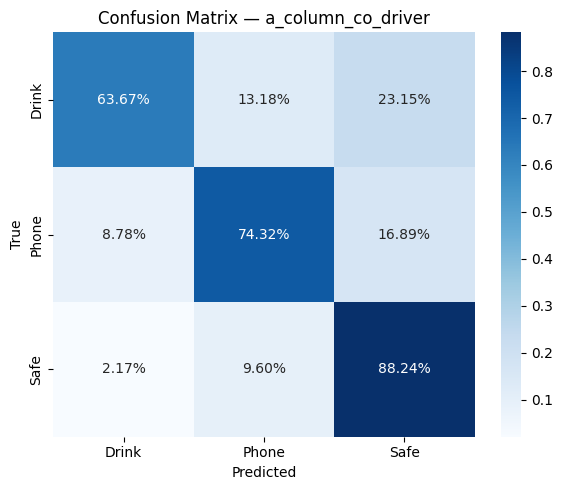

time: 196 ms (started: 2026-04-08 19:59:57 +00:00)


In [15]:
cm = confusion_matrix(labels_all, preds_all, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=cfg['classes'], yticklabels=cfg['classes'], ax=ax)
ax.set_xlabel('Predicted');  ax.set_ylabel('True')
ax.set_title(f"Confusion Matrix — {cfg['camera']}")
plt.tight_layout()
plt.show()

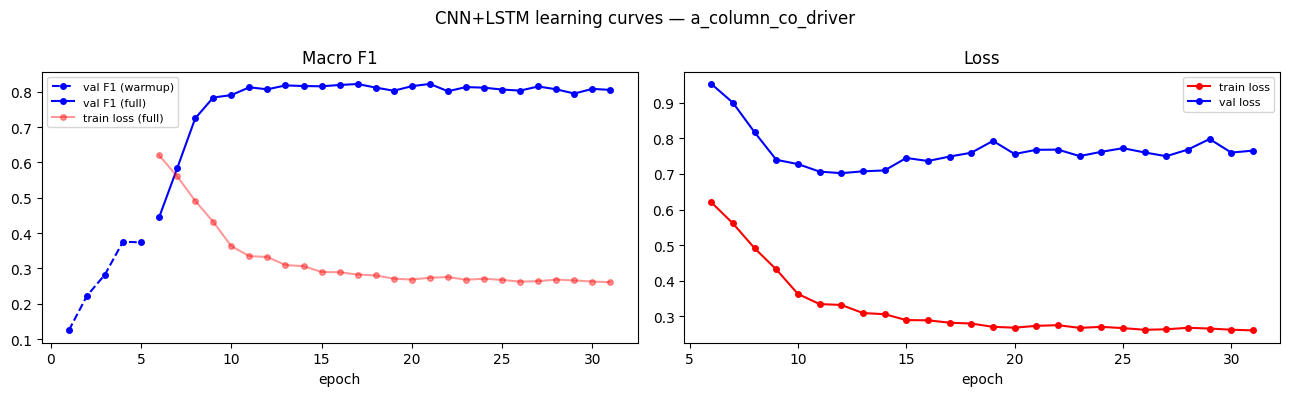

time: 319 ms (started: 2026-04-08 19:59:57 +00:00)


In [16]:
# learning curves — warmup (val only) + full (train + val)
nw   = len(hist['vf'])
xs_w = list(range(1, nw + 1))
xs_f = list(range(nw + 1, nw + len(hist2['vf']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (vkey, tkey, title) in zip(axes, [('vf', 'tl', 'Macro F1 / Loss'), ('vl', 'tl', 'Loss')]):
    ax.plot(xs_w, hist['vf'],   'b--o', ms=4, label='val F1 (warmup)')
    ax.plot(xs_f, hist2['vf'],  'b-o',  ms=4, label='val F1 (full)')
    ax.plot(xs_f, hist2['tl'],  'r-o',  ms=4, alpha=0.4, label='train loss (full)')
    ax.set_xlabel('epoch');  ax.legend(fontsize=8)

axes[0].set_title('Macro F1')
axes[1].set_title('Train Loss (full phase)')
axes[1].cla()
axes[1].plot(xs_f, hist2['tl'], 'r-o', ms=4, label='train loss')
axes[1].plot(xs_f, hist2['vl'], 'b-o', ms=4, label='val loss')
axes[1].set_title('Loss');  axes[1].legend(fontsize=8);  axes[1].set_xlabel('epoch')

plt.suptitle(f"CNN+LSTM learning curves — {cfg['camera']}")
plt.tight_layout()
plt.show()

## Save

In [17]:
dst = f'/content/drive/MyDrive/DriveGuard/models/{cfg["ckpt"]}'
os.makedirs(os.path.dirname(dst), exist_ok=True)

if os.path.exists(cfg['ckpt']):
    shutil.copy(cfg['ckpt'], dst)
    print(f'saved to {dst}  ({os.path.getsize(dst)/1e6:.2f} MB)')
    print(f'best val macro F1: {best_f1:.4f}')
else:
    print('checkpoint not found')

saved to /content/drive/MyDrive/DriveGuard/models/lstm_temporal_head_model.pth  (45.70 MB)
best val macro F1: 0.8221
time: 113 ms (started: 2026-04-08 19:59:58 +00:00)


## Hard Failures

In [18]:
net.eval()
bad = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc='scanning'):
        x = x.to(dev)
        if amp_dtype:
            with torch.amp.autocast('cuda', amp_dtype):
                probs = torch.softmax(net(x).float(), dim=1)
        else:
            probs = torch.softmax(net(x).float(), dim=1)
        pred = probs.argmax(1).cpu()
        conf = probs.max(1).values.cpu()
        for i in (pred != y).nonzero(as_tuple=True)[0]:
            bad.append((cfg['classes'][y[i]], cfg['classes'][pred[i].item()], conf[i].item()))

bad.sort(key=lambda t: -t[2])
print(f'{len(bad)} failures / {len(test_ds)}  ({100*len(bad)/len(test_ds):.1f}% error rate)\n')
print(f'{"true":8}  {"pred":8}  {"conf":>8}')
print('-' * 28)
for t, p, c in bad[:15]:
    print(f'{t:8}  {p:8}  {c:8.4f}')

pairs = defaultdict(int)
for t, p, _ in bad: pairs[(t, p)] += 1
print('\npairs (true -> pred : n):')
for (t, p), n in sorted(pairs.items(), key=lambda x: -x[1]):
    print(f'  {t} -> {p} : {n}')

scanning:   0%|          | 0/25 [00:00<?, ?it/s]

189 failures / 782  (24.2% error rate)

true      pred          conf
----------------------------
Drink     Phone       0.9279
Drink     Safe        0.9142
Safe      Phone       0.9013
Phone     Safe        0.8986
Drink     Safe        0.8945
Drink     Safe        0.8811
Phone     Safe        0.8620
Drink     Safe        0.8594
Phone     Safe        0.8364
Drink     Phone       0.8349
Phone     Safe        0.8327
Drink     Safe        0.8241
Drink     Safe        0.8240
Drink     Safe        0.8216
Phone     Drink       0.8196

pairs (true -> pred : n):
  Drink -> Safe : 72
  Drink -> Phone : 41
  Safe -> Phone : 31
  Phone -> Safe : 25
  Phone -> Drink : 13
  Safe -> Drink : 7
time: 175 ms (started: 2026-04-08 19:59:58 +00:00)
